# Function 2D: Evolutionary optimization tutorial

Tutorial for **`docs_private/40_notes_and_references/10_evolutionary_methods/evolutionary_methods_guide.md`**: optimize a 2D synthetic function with **Genetic Algorithm (GA)** and **Evolution Strategy ((μ,λ)-ES)**.

- **GA:** real-valued, tournament selection, blend crossover, Gaussian mutation.
- **ES:** (μ,λ)-ES — mutation only, no crossover; good for continuous space (guide, section 4).
- **Domain:** \([0,1]^2\) (same as BBO challenge F1–F2).
- **BO:** GP surrogate + Expected Improvement (EI); sample-efficient comparison.
- **Concepts:** population, fitness, selection, variation; BO uses a GP surrogate.

## 1. Setup and imports

In [16]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings

repo_root = Path.cwd()
for _ in range(5):
    if (repo_root / "src").exists(): break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

warnings.filterwarnings("ignore")


## 2. 2D synthetic function and parameters

**Challenging deterministic part:** multiple scales (sinusoids + Gaussian bumps) with many local optima. **Noise:** additive Gaussian on evaluations so optimizers see a noisy objective. Contour and true max use the deterministic part; runs use the noisy function. Goal: **maximize** \(f(x)\).

In [17]:
# ==== Challenging 2D objective: multi-scale sinusoids + Gaussian bumps (many local optima) ====
def objective_2d(x):
    """Deterministic part on [0,1]^2. x: (n, 2) or (2,). Returns (n,) or scalar."""
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x1, x2 = x[:, 0], x[:, 1]
    # High-frequency sinusoids (rugged)
    v = (np.sin(5 * np.pi * x1) + 0.7 * np.sin(4 * np.pi * x2)
         + 0.5 * np.cos(7 * np.pi * (x1 + x2)) + 0.3 * np.cos(11 * np.pi * x1 * x2)
         + 0.4 * np.sin(8 * np.pi * (x1 - 0.3)) * np.cos(6 * np.pi * x2)) * 0.22 + 0.5
    # Gaussian bumps (sharp local peaks)
    bumps = (0.35 * np.exp(-((x1 - 0.2)**2 + (x2 - 0.7)**2) / 0.03)
             + 0.4 * np.exp(-((x1 - 0.75)**2 + (x2 - 0.25)**2) / 0.02)
             + 0.25 * np.exp(-((x1 - 0.5)**2 + (x2 - 0.5)**2) / 0.04))
    v = v + bumps
    return v.ravel() if v.size > 1 else float(np.asarray(v).flat[0])

# Noisy wrapper for optimization (same x can get different values across runs; fixed seed per run)
def make_noisy_fun(fun, noise_std, seed=42):
    rng = np.random.default_rng(seed)
    def noisy(x):
        out = fun(x)
        arr = np.atleast_1d(np.asarray(out, dtype=float))
        arr = arr + noise_std * rng.standard_normal(arr.shape)
        return arr.ravel() if arr.size > 1 else float(arr.flat[0])
    return noisy

NOISE_STD = 0.08
true_function_2d = make_noisy_fun(objective_2d, NOISE_STD, seed=42)

# Bounds and EA parameters (see evolutionary_methods_guide.md)
bounds_2d = np.array([[0.0, 1.0], [0.0, 1.0]])
# Same single starting point for all methods (every optimizer starts from here)
x_start = np.array([0.1, 0.1])  # corner, away from typical maxima (bumps near 0.2/0.7, 0.75/0.25, 0.5/0.5)
X_initial = x_start.reshape(1, 2)
N_INITIAL = 1
N_QUERIES = 50  # same evaluation budget for all methods (fair comparison)
POP_SIZE = 1
N_GENERATIONS = 50
TOURNAMENT_SIZE = 2
MUTATION_SIGMA = 0.08
CROSSOVER_PROB = 0.7

# Grid for plotting (use deterministic part so contour and true max are interpretable)
n_plot = 80
xx = np.linspace(0, 1, n_plot)
yy = np.linspace(0, 1, n_plot)
X_grid, Y_grid = np.meshgrid(xx, yy)
Z_true = objective_2d(np.column_stack([X_grid.ravel(), Y_grid.ravel()])).reshape(n_plot, n_plot)

## 3. Minimal GA (evolutionary_methods_guide, section 3)

Tournament selection, blend crossover, Gaussian mutation.

### 3b. Evolution Strategy: \((\mu,\lambda)\)-ES

**GA** uses selection + crossover + mutation. **Evolution Strategies (ES)** typically use **mutation only**: sample \(\lambda\) offspring from a Gaussian around the current mean; keep best \(\mu\) to update the distribution. No crossover. Good for continuous space. See `evolutionary_methods_guide.md`, section 4.

In [18]:
# (μ,λ)-ES: mutation only, no crossover. Sample λ from N(m,σ²I); keep best μ; new m = weighted mean.
def run_es_2d(fun, bounds, mu, lam, n_generations, sigma, seed=42, X_initial=None):
    """(μ,λ)-ES: sample λ from N(m, σ²I), evaluate, take best μ; m = weighted mean (best has more weight). Maximize fun."""
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None and len(X_initial) >= 1:
        m = np.mean(np.asarray(X_initial)[:5], axis=0)
    else:
        m = rng.uniform(bounds[:, 0], bounds[:, 1], size=d)
    best_y = -np.inf
    best_x = m.copy()
    history = []
    trajectory = [m.copy()]  # mean (or best) per generation for contour trajectory plot
    # Weights for recombination: best of top-μ gets highest weight (standard in ES)
    weights = np.log(mu + 1) - np.log(np.arange(1, mu + 1))
    weights = weights / weights.sum()
    for gen in range(n_generations):
        # sample λ offspring
        z = rng.standard_normal(size=(lam, d))
        pop = m + sigma * z
        pop = np.clip(pop, bounds[:, 0], bounds[:, 1])
        fit_raw = fun(pop)
        fitness = np.asarray(fit_raw).ravel()  # ensure shape (lam,)
        # (μ,λ): keep best μ from offspring only; idx[0] = best
        idx = np.argsort(fitness)[::-1][:mu]
        top = pop[idx]
        m = np.average(top, axis=0, weights=weights)
        best_this_gen = float(fitness[idx[0]])
        if best_this_gen > best_y:
            best_y = best_this_gen
            best_x = pop[idx[0]].copy()
        history.append(best_y)
        trajectory.append(m.copy())
    return pop, fitness, best_x, best_y, history, trajectory

### 3c. Bayesian optimization (GP + EI)

Fit a **Gaussian process** on observed \((X, y)\), then choose the next point by maximizing **Expected Improvement (EI)**. Sample-efficient (few evaluations); compare to GA/ES which use many evaluations per generation.

In [19]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from src.optimizers.my_bayesian import expected_improvement

def run_bo_2d(fun, bounds, n_evaluations, n_initial=5, seed=42, X_initial=None, noise_std=0.08):
    """Bayesian optimization: GP surrogate + EI. Maximize fun. Returns (X, y, best_x, best_y, history).
    Uses RBF + WhiteKernel (observation noise), fitted length scale, finer EI grid, and moderate xi."""
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None:
        X = np.asarray(X_initial)[:n_initial]
    else:
        X = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_initial, d))
    y = np.asarray(fun(X)).ravel()
    n_init_used = len(X)
    best_so_far = np.max(y)
    history = [best_so_far] * n_init_used  # one entry per initial eval for alignment with GA/ES
    # Kernel: RBF with fitted length scale + WhiteKernel for observation noise (helps with noisy objectives)
    kernel = (ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0))
              * RBF(length_scale=0.25, length_scale_bounds=(0.06, 0.8))
              + WhiteKernel(noise_level=noise_std**2, noise_level_bounds=(1e-6, 1.0)))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=4)
    n_opt = 80  # finer grid to better locate EI maximum (narrow bumps in objective)
    xi_ei = 0.04   # moderate exploration (higher than 0.01) when starting from one point
    for _ in range(n_evaluations - n_init_used):
        gp.fit(X, y)
        xx_opt = np.linspace(bounds[0, 0], bounds[0, 1], n_opt)
        yy_opt = np.linspace(bounds[1, 0], bounds[1, 1], n_opt)
        X_cand = np.column_stack([x.ravel() for x in np.meshgrid(xx_opt, yy_opt)])
        mu, sigma = gp.predict(X_cand, return_std=True)
        sigma = np.maximum(sigma, 1e-9)
        y_best = np.max(y)
        ei = expected_improvement(mu, sigma, y_best, xi=xi_ei)
        i_best = np.argmax(ei)
        x_next = X_cand[i_best : i_best + 1]
        y_next = float(np.asarray(fun(x_next)).flat[0])
        X = np.vstack([X, x_next])
        y = np.append(y, y_next)
        best_so_far = max(best_so_far, y_next)
        history.append(best_so_far)
    best_idx = np.argmax(y)
    best_x = X[best_idx].copy()
    best_y = float(y[best_idx])
    return X, y, best_x, best_y, history

### 3d. Other methods (baselines and alternatives)

| Method | Idea | Use case |
|--------|------|----------|
| **Simulated annealing (SA)** | Single point; accept worse moves with probability ∝ exp(Δ/T); T decreases. | Escape local optima; few evals. |
| **Particle Swarm (PSO)** | Swarm with velocity; attracted to personal best and global best. | Continuous, robust. |
| **Differential Evolution (DE)** | Mutate using differences between individuals; crossover. | Global, robust. |
| **CMA-ES** | Adapt full covariance of Gaussian (guide, section 4.3). | State-of-the-art ES; e.g. Nevergrad. |
| **Nelder-Mead** | Simplex steps (reflect, expand, contract). | Local, derivative-free. |

Below: **Simulated Annealing** (same evaluation budget as BO for fair comparison).

In [20]:
def run_simulated_annealing_2d(fun, bounds, n_evaluations, sigma=0.1, T_start=0.5, seed=42, X_initial=None):
    """Simulated annealing: single point, Gaussian neighbour; accept worse with prob exp(Δ/T). Maximize fun."""
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None and len(X_initial) >= 1:
        X0 = np.asarray(X_initial)[:5]
        y0 = np.asarray(fun(X0)).ravel()
        x = X0[np.argmax(y0)].copy()
        y = float(np.max(y0))
        n_steps = n_evaluations - len(X0)
        history = [y] * len(X0)
    else:
        x = rng.uniform(bounds[:, 0], bounds[:, 1], size=d)
        y = float(np.asarray(fun(x.reshape(1, -1))).flat[0])
        n_steps = n_evaluations - 1
        history = [y]
    best_x, best_y = x.copy(), y
    trajectory = [x.copy()]
    for i in range(n_steps):
        T = T_start * (1 - (i + 1) / n_steps)  # linear cooling
        x_new = x + sigma * rng.standard_normal(size=d)
        x_new = np.clip(x_new, bounds[:, 0], bounds[:, 1])
        y_new = float(np.asarray(fun(x_new.reshape(1, -1))).flat[0])
        delta = y_new - y
        if delta >= 0 or rng.random() < np.exp(delta / max(T, 1e-10)):
            x, y = x_new, y_new
        trajectory.append(x.copy())
        if y > best_y:
            best_x, best_y = x.copy(), y
        history.append(best_y)
    return np.array(trajectory), best_x, best_y, history

In [21]:
def select_tournament(pop, fitness, n_parents, k=2, rng=None):
    rng = rng or np.random.default_rng()
    n = len(pop)
    parents = []
    for _ in range(n_parents):
        idx = np.atleast_1d(rng.choice(n, size=min(k, n), replace=False))
        winner = idx[np.argmax(fitness[idx])]
        parents.append(pop[winner])
    return np.array(parents)

def crossover_blend(p1, p2, prob=0.7, rng=None):
    rng = rng or np.random.default_rng()
    if rng.random() > prob:
        return p1.copy()
    alpha = rng.random(size=p1.shape)
    return alpha * p1 + (1 - alpha) * p2

def mutate_gaussian(x, sigma, bounds, rng=None):
    rng = rng or np.random.default_rng()
    x = x + sigma * rng.standard_normal(size=x.shape)
    return np.clip(x, bounds[:, 0], bounds[:, 1])

def run_ga_2d(fun, bounds, pop_size, n_generations, sigma, crossover_prob, tournament_k, seed=42, X_initial=None):
    rng = np.random.default_rng(seed)
    d = bounds.shape[0]
    if X_initial is not None and len(X_initial) >= 1:
        # All individuals start from the same point (with small perturbation for diversity)
        start = np.asarray(X_initial[0]).ravel()
        pop = start + sigma * rng.standard_normal(size=(pop_size, d))
        pop = np.clip(pop, bounds[:, 0], bounds[:, 1])
    else:
        pop = rng.uniform(bounds[:, 0], bounds[:, 1], size=(pop_size, d))
    fitness = np.atleast_1d(np.asarray(fun(pop)).ravel())  # ensure (n,) even for pop_size=1
    best_y = float(np.max(fitness))
    best_x = pop[np.argmax(fitness)].copy()
    history = [best_y]
    start_pt = (np.asarray(X_initial[0]).ravel().copy() if (X_initial is not None and len(X_initial) >= 1) else best_x.copy())
    trajectory = [start_pt]  # same starting point for all methods
    for gen in range(n_generations - 1):
        parents = select_tournament(pop, fitness, n_parents=pop_size, k=tournament_k, rng=rng)
        offspring = []
        for i in range(0, pop_size, 2):
            p1, p2 = parents[i], parents[min(i + 1, pop_size - 1)]
            c1 = crossover_blend(p1, p2, prob=crossover_prob, rng=rng)
            c2 = crossover_blend(p2, p1, prob=crossover_prob, rng=rng)
            offspring.append(mutate_gaussian(c1, sigma, bounds, rng))
            offspring.append(mutate_gaussian(c2, sigma, bounds, rng))
        pop = np.array(offspring[:pop_size])
        fitness = np.atleast_1d(np.asarray(fun(pop)).ravel())
        if np.max(fitness) > best_y:
            best_y = float(np.max(fitness))
            best_x = pop[np.argmax(fitness)].copy()
        history.append(best_y)
        trajectory.append(best_x.copy())
    return pop, fitness, best_x, best_y, history, trajectory

## 4. Run and plot

True max: y=1.1847 at (x1=0.139, x2=0.684)
Method   |  Steps  | Queries | Final err %
---------|--------|--------|------------
GA       |     50 |     50 | 9.80%
ES       |     50 |     50 | 14.42%
BO       |     50 |     50 | -17.93%
SA       |     50 |     50 | 13.12%
Total queries: 200


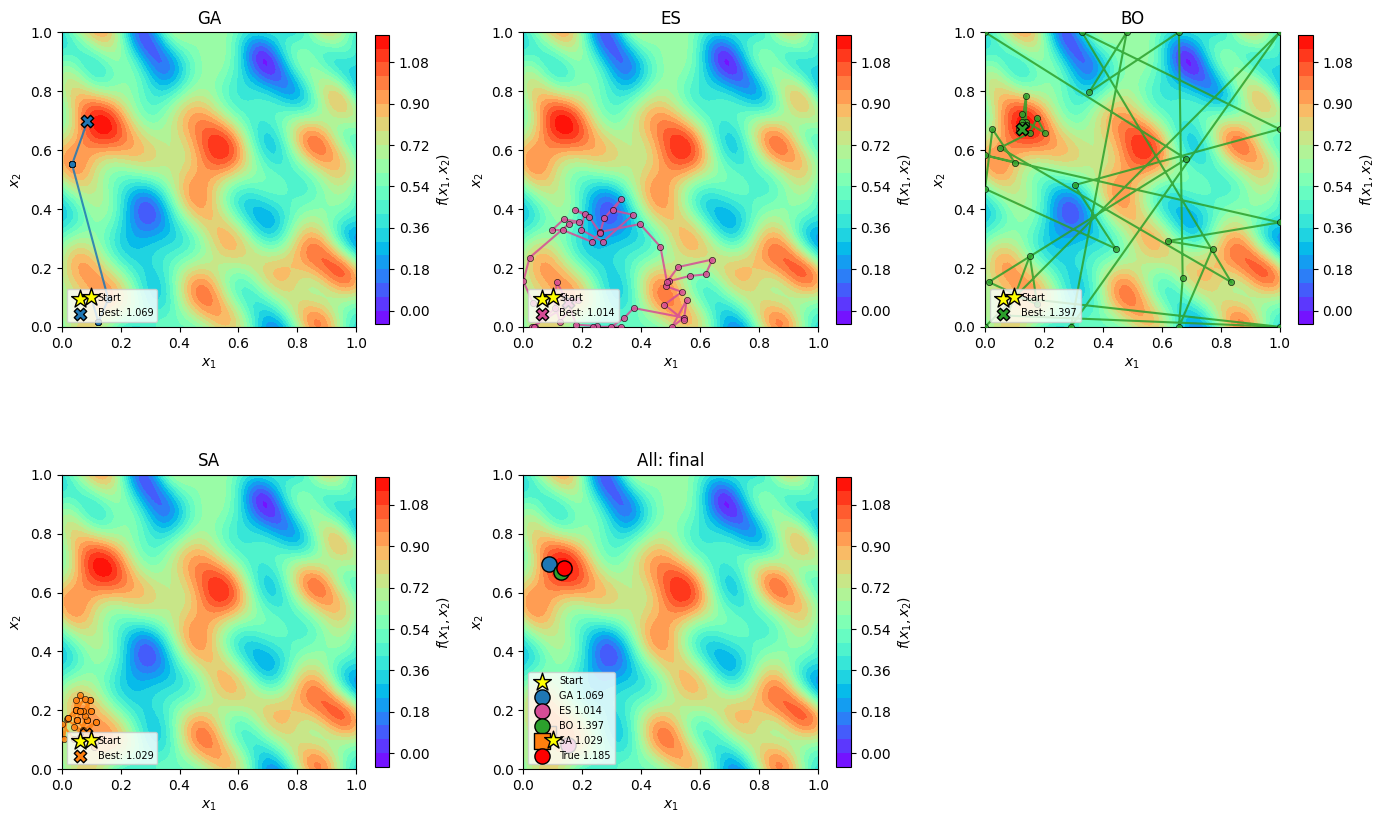

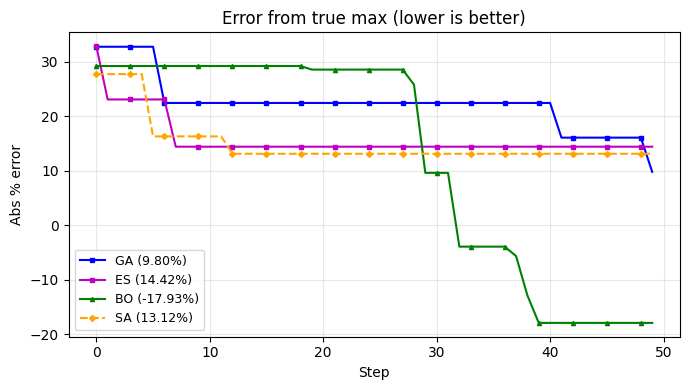

In [22]:
# True max over the plotting grid (for reference on the figure)
true_max = np.max(Z_true)
true_min = np.min(Z_true)
ij_max = np.unravel_index(np.argmax(Z_true), Z_true.shape)
x1_max, x2_max = xx[ij_max[1]], yy[ij_max[0]]

# Run all methods (same query budget each)
MU, LAM = 1, 1
N_BO_EVALS = N_QUERIES
pop_2d, fit_2d, best_x_2d, best_y_2d, history_2d, trajectory_ga = run_ga_2d(
    true_function_2d, bounds_2d, POP_SIZE, N_GENERATIONS,
    MUTATION_SIGMA, CROSSOVER_PROB, TOURNAMENT_SIZE, seed=42, X_initial=X_initial)
_, _, best_x_es, best_y_es, history_es, trajectory_es = run_es_2d(
    true_function_2d, bounds_2d, MU, LAM, N_GENERATIONS, MUTATION_SIGMA, seed=42, X_initial=X_initial)
X_bo, y_bo, best_x_bo, best_y_bo, history_bo = run_bo_2d(
    true_function_2d, bounds_2d, N_BO_EVALS, n_initial=5, seed=42, X_initial=X_initial, noise_std=NOISE_STD)
trajectory_bo = np.asarray(X_bo)
trajectory_sa, best_x_sa, best_y_sa, history_sa = run_simulated_annealing_2d(
    true_function_2d, bounds_2d, N_QUERIES, sigma=0.08, T_start=0.3, seed=42, X_initial=X_initial)

queries_ga = len(history_2d) * POP_SIZE
queries_es = len(history_es) * LAM
queries_bo = len(history_bo)
queries_sa = len(history_sa)
total_queries = queries_ga + queries_es + queries_bo + queries_sa
denom = max(true_max, 1e-10)
err_ga = 100 * (true_max - np.array(history_2d)) / denom
err_es = 100 * (true_max - np.array(history_es)) / denom
err_bo = 100 * (true_max - np.array(history_bo)) / denom
err_sa = 100 * (true_max - np.array(history_sa)) / denom

print("True max:", f"y={true_max:.4f}", f"at (x1={x1_max:.3f}, x2={x2_max:.3f})")
print("Method   |  Steps  | Queries | Final err %")
print("---------|--------|--------|------------")
print(f"GA       | {len(history_2d):6} | {queries_ga:6} | {err_ga[-1]:.2f}%")
print(f"ES       | {len(history_es):6} | {queries_es:6} | {err_es[-1]:.2f}%")
print(f"BO       | {len(history_bo):6} | {queries_bo:6} | {err_bo[-1]:.2f}%")
print(f"SA       | {len(history_sa):6} | {queries_sa:6} | {err_sa[-1]:.2f}%")
print(f"Total queries: {total_queries}")

# --- Contour plots ---
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

def plot_contour_trajectory(ax, trajectory, best_x, best_y, color, title, label="best", x_start=None):
    cf = ax.contourf(X_grid, Y_grid, Z_true, levels=20, cmap="rainbow")
    plt.colorbar(cf, ax=ax, label="$f(x_1, x_2)$", shrink=0.7)
    if x_start is not None:
        ax.scatter(x_start[0], x_start[1], c="yellow", s=180, marker="*", edgecolors="k", linewidths=1, zorder=6, label="Start")
    tr = np.asarray(trajectory)
    ax.plot(tr[:, 0], tr[:, 1], color=color, lw=1.5, alpha=0.85)
    ax.scatter(tr[:, 0], tr[:, 1], c=color, s=20, alpha=0.8, edgecolors="k", linewidths=0.5, zorder=3)
    ax.scatter(best_x[0], best_x[1], c=color, s=80, marker="X", edgecolors="k", linewidths=1, zorder=5, label=f"Best: {best_y:.3f}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.legend(loc="lower left", fontsize=7)

plot_contour_trajectory(axes[0], trajectory_ga, best_x_2d, best_y_2d, "#1f77b4", "GA", "GA", x_start=x_start)
plot_contour_trajectory(axes[1], trajectory_es, best_x_es, best_y_es, "#d64c96", "ES", "ES", x_start=x_start)
plot_contour_trajectory(axes[2], trajectory_bo, best_x_bo, best_y_bo, "#2ca02c", "BO", "BO", x_start=x_start)
plot_contour_trajectory(axes[3], trajectory_sa, best_x_sa, best_y_sa, "#ff7f0e", "SA", "SA", x_start=x_start)

ax = axes[4]
cf = ax.contourf(X_grid, Y_grid, Z_true, levels=20, cmap="rainbow")
plt.colorbar(cf, ax=ax, label="$f(x_1, x_2)$", shrink=0.7)
ax.scatter(x_start[0], x_start[1], c="yellow", s=180, marker="*", edgecolors="k", zorder=6, label="Start")
ax.scatter(best_x_2d[0], best_x_2d[1], c="#1f77b4", s=120, marker="o", edgecolors="k", zorder=5, label=f"GA {best_y_2d:.3f}")
ax.scatter(best_x_es[0], best_x_es[1], c="#d64c96", s=120, marker="o", edgecolors="k", zorder=5, label=f"ES {best_y_es:.3f}")
ax.scatter(best_x_bo[0], best_x_bo[1], c="#2ca02c", s=120, marker="o", edgecolors="k", zorder=5, label=f"BO {best_y_bo:.3f}")
ax.scatter(best_x_sa[0], best_x_sa[1], c="#ff7f0e", s=120, marker="s", edgecolors="k", zorder=5, label=f"SA {best_y_sa:.3f}")
ax.scatter(x1_max, x2_max, c="red", s=120, marker="o", edgecolors="k", zorder=5, label=f"True {true_max:.3f}")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("All: final")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=7)
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

# --- Error over time ---
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 4))
ax2.plot(err_ga, "b-", lw=1.5, marker="s", markersize=3, markevery=max(1, len(err_ga)//15), label=f"GA ({err_ga[-1]:.2f}%)")
ax2.plot(err_es, "m-", lw=1.5, marker="s", markersize=3, markevery=max(1, len(err_es)//15), label=f"ES ({err_es[-1]:.2f}%)")
ax2.plot(err_bo, color="green", lw=1.5, marker="^", markersize=3, markevery=max(1, len(err_bo)//15), label=f"BO ({err_bo[-1]:.2f}%)")
ax2.plot(err_sa, color="orange", linestyle="--", lw=1.5, marker="D", markersize=3, markevery=max(1, len(err_sa)//15), label=f"SA ({err_sa[-1]:.2f}%)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Abs % error")
ax2.set_title("Error from true max (lower is better)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Summary (evolutionary methods guide)

| Concept | GA | (μ,λ)-ES | BO (GP+EI) |
|--------|-----|----------|------------|
| **Population / evals** | 40/gen | λ=40/gen | 30 total |
| **Surrogate** | None | None | GP (RBF) |
| **Next point** | Selection + crossover + mutation | Best μ → new mean | argmax EI |
| **Efficiency** | Many evals/gen | Many evals/gen | Few evals (sample-efficient) |

For BBO (one query per week): use observed \((X,y)\) as population and/or a surrogate to score offspring, or **Nevergrad** (CMA-ES)—see `evolutionary_methods_guide.md`, section 6.

## 6. MyBO vs Open Source Commonly Used Optimization Solvers

Given the observations collected by the internal BO run, compare what each solver would suggest as the **next query** in 2D. **Summary figure:** contour map of the true function, BO observation points as black dots, each solver's suggested next \((x_1, x_2)\) shown as a coloured hollow marker. Bounds: \([0,1]^2\). Different seeds per solver promote diversity; it is normal for solvers to agree when the acquisition landscape has a dominant peak.

[I 2026-03-17 13:43:06,131] A new study created in memory with name: no-name-69344352-2884-4083-9040-59b71ba6dfb9


Skipping TuRBO: (0.1230, 0.6813) — within 0.0042 of obs (0.1266, 0.6835)


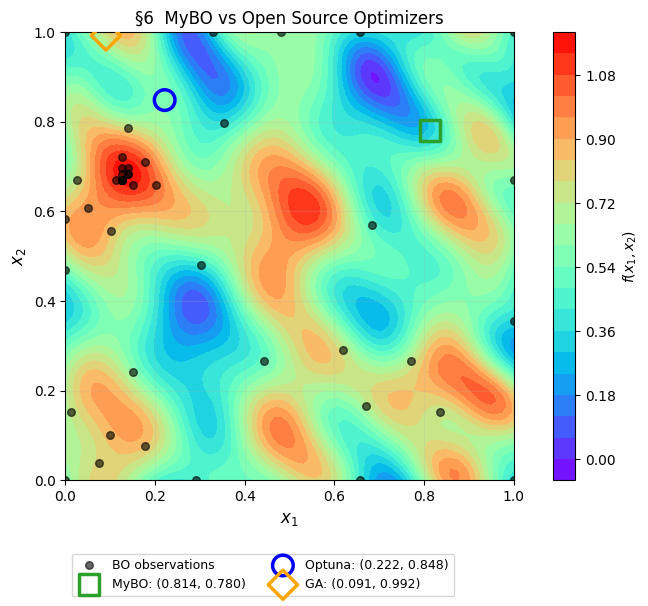

In [23]:
# MyBO = this notebook's BO (GP+EI) pipeline — compute next EI suggestion from the final GP fit.
# Optuna, TuRBO, GA = external solver suggestions on the same (X_bo, y_bo) observations.
# TuRBO requires BoTorch: pip install botorch (if you see "TuRBO skipped").

# Bounds as list-of-tuples (wrapper interface)
bounds_2d_list = [(float(bounds_2d[i, 0]), float(bounds_2d[i, 1])) for i in range(bounds_2d.shape[0])]

# Fixed per-solver style: colour/marker never shift if a solver is skipped.
SOLVER_STYLES = {
    "MyBO":   ("#2ca02c", "s"),
    "Optuna": ("blue",    "o"),
    "TuRBO":  ("#d64c96", "^"),
    "GA":     ("orange",  "D"),
}

# MyBO: refit final GP on BO observations, find argmax EI as the suggested next point.
_kernel_s6 = (ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0))
              * RBF(length_scale=0.25, length_scale_bounds=(0.06, 0.8))
              + WhiteKernel(noise_level=NOISE_STD**2, noise_level_bounds=(1e-6, 1.0)))
_gp_s6 = GaussianProcessRegressor(kernel=_kernel_s6, alpha=1e-6, normalize_y=True, n_restarts_optimizer=2)
_gp_s6.fit(X_bo, y_bo)
_n_s6 = 60
_xx_s6 = np.linspace(0, 1, _n_s6)
_yy_s6 = np.linspace(0, 1, _n_s6)
_X_cand_s6 = np.column_stack([v.ravel() for v in np.meshgrid(_xx_s6, _yy_s6)])
_mu_s6, _sigma_s6 = _gp_s6.predict(_X_cand_s6, return_std=True)
_sigma_s6 = np.maximum(_sigma_s6, 1e-9)
_ei_s6 = expected_improvement(_mu_s6, _sigma_s6, np.max(y_bo), xi=0.04)
mybo_next = _X_cand_s6[np.argmax(_ei_s6)]

suggestions_2d = [("MyBO", mybo_next)]

def _try_suggest_2d(name, mod_path, kwargs):
    try:
        mod = __import__(mod_path, fromlist=["suggest"])
        x_pt = np.asarray(mod.suggest(X_bo, y_bo, **kwargs)).ravel()
        return (name, x_pt)
    except Exception as e:
        print(f"{name} skipped — {e}")
        return None

# Optuna CMA-ES is more local than TPE (better with few observations).
# Different seeds per solver promote diversity in suggestions.
for name, mod, kw in [
    ("Optuna", "src.optimizers.wrappers.optuna_solver", {"bounds": bounds_2d_list, "seed": 42, "sampler": "cmaes"}),
    ("TuRBO",  "src.optimizers.wrappers.turbo_solver",  {"bounds": bounds_2d_list, "seed": 43}),
    ("GA",     "src.optimizers.wrappers.de_gp_ei_solver",     {"bounds": bounds_2d_list, "seed": 44}),
]:
    r = _try_suggest_2d(name, mod, kw)
    if r is not None:
        suggestions_2d.append(r)

# Drop suggestions that land too close to an existing observation (redundant query).
_dup_tol_2d = 0.01  # Euclidean distance threshold (domain is [0,1]²)

def _nearest_obs_2d(x_s):
    dists = np.linalg.norm(X_bo - np.asarray(x_s), axis=1)
    idx = int(np.argmin(dists))
    return float(dists[idx]), X_bo[idx]

suggestions_2d_filtered = []
for name, x_s in suggestions_2d:
    d_obs, x_obs = _nearest_obs_2d(x_s)
    if d_obs < _dup_tol_2d:
        print(f"Skipping {name}: ({x_s[0]:.4f}, {x_s[1]:.4f}) — within {d_obs:.4f} of obs ({x_obs[0]:.4f}, {x_obs[1]:.4f})")
        continue
    suggestions_2d_filtered.append((name, x_s))

# 2D comparison plot: contour + BO observations + solver suggestions
fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(X_grid, Y_grid, Z_true, levels=20, cmap="rainbow")
plt.colorbar(cf, ax=ax, label="$f(x_1, x_2)$")
ax.scatter(X_bo[:, 0], X_bo[:, 1], c="black", s=30, edgecolors="k",
           linewidths=1, zorder=5, alpha=0.6, label="BO observations")

for name, x_s in suggestions_2d_filtered:
    col, mk = SOLVER_STYLES.get(name, ("gray", "o"))
    ax.scatter(x_s[0], x_s[1], s=220, marker=mk, c="none",
               edgecolors=col, linewidths=2.5, zorder=10,
               label=f"{name}: ({x_s[0]:.3f}, {x_s[1]:.3f})")

ax.set_xlabel("$x_1$", fontsize=12)
ax.set_ylabel("$x_2$", fontsize=12)
ax.set_title("Section 6  MyBO vs Open Source Optimizers")
ax.legend(loc="upper left", fontsize=9, ncol=2, frameon=True, bbox_to_anchor=(0.0, -0.15))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.show()